# Final Project: Automated Image Colorization
**Course: Deep Learning / Computer Vision Assignment**

---

# Image Colorization With a Convolutional Neural Network

This notebook implements an image colorization model using a convolutional neural network (CNN). The task is to take a grayscale image as input and predict plausible color information for that image.

The dataset is represented in **LAB color space**:

- **L channel**: lightness, which appears as a grayscale image
- **A and B channels**: color-opponent channels that encode the missing color information

Instead of predicting a full RGB image directly, the model receives the L channel and learns to predict the A/B channels. The final RGB image is reconstructed by combining the original L channel with the predicted A/B channels and converting from LAB to RGB. This is a common approach because it separates brightness from color and lets the CNN focus on the colorization problem.

## 1. Notebook Backend

This cell configures Matplotlib so figures appear directly inside the notebook output. It does not affect model training, but it makes the visual results easier to inspect.

In [62]:
%matplotlib inline

## 2. Environment Check

This cell verifies that the required Python packages are available. OpenCV is used for LAB-to-RGB conversion, Matplotlib is used for visualization, NumPy is used for array processing, and TensorFlow/Keras is used to build and train the CNN.

In [63]:
import sys
from pathlib import Path

print(f"Python executable: {sys.executable}")
expected_venv = (Path.cwd() / ".venv" / "Scripts" / "python.exe").resolve()
print(f"Expected workspace venv: {expected_venv}")

try:
    import cv2
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "OpenCV is not installed in the active notebook kernel. "
        "In VS Code, select the kernel/interpreter at .venv\\Scripts\\python.exe, "
        "then restart the kernel and run from the top."
    ) from exc

print(f"OpenCV version: {cv2.__version__}")

Python executable: /usr/bin/python3
Expected workspace venv: /content/.venv/Scripts/python.exe
OpenCV version: 4.13.0


## 3. Imports and Experiment Settings

The constants in this cell define the size of the experiment, the CNN capacity, the loss-function weights, and the output paths. The settings are chosen to run in a standard Google Colab session while still training on a meaningful subset of the dataset.

The model uses a compact U-Net-style CNN with single-channel grayscale input. The loss function combines pixel-level color error, chroma error, edge error, and a color-bias penalty. This helps the model learn color while reducing common failure modes such as washed-out predictions or a strong yellow/brown color cast.

Only a validation subset is converted to RGB for presentation figures. This keeps memory usage manageable because converting every image and prediction to RGB at once can require several gigabytes of RAM.

In [64]:
from pathlib import Path
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import cv2
import matplotlib.pyplot as plt
import numpy as np

print("Importing TensorFlow...", flush=True)
import tensorflow as tf
from tensorflow.keras.layers import (
    BatchNormalization,
    Concatenate,
    Conv2D,
    Dropout,
    Input,
    MaxPooling2D,
    UpSampling2D,
)
from tensorflow.keras.models import Model

SAMPLE_COUNT = 1600
EPOCHS = 40
BATCH_SIZE = 4
VALIDATION_SPLIT = 0.2
RANDOM_SEED = 42
BASE_FILTERS = 16
DROPOUT_RATE = 0.1
CHROMA_LOSS_WEIGHT = 0.95
COLORFUL_PIXEL_WEIGHT = 2.0
EDGE_LOSS_WEIGHT = 0.05
COLOR_BIAS_LOSS_WEIGHT = 0.45
CHROMA_UNDERSAT_WEIGHT = 2.0
CHROMA_UNDERSAT_RATIO = 5.0
DISPLAY_CHROMA_BOOST = 1.3
EVAL_COUNT = 64
QUALITATIVE_EXAMPLE_COUNT = 6
MIN_TARGET_CHROMA = 0.04
HUE_BIN_COUNT = 12
TRANSLATION_AUGMENT_FRACTION = 0.0
AB_JITTER_STD = 0.03

OUTPUT_DIR = Path("outputs")
BEST_WEIGHTS_PATH = OUTPUT_DIR / "best_colorization.weights.h5"
MODEL_DIAGRAM_PATH = OUTPUT_DIR / "model_architecture.png"
TRAINING_LOG_PATH = OUTPUT_DIR / "training_log.csv"

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"OpenCV version: {cv2.__version__}")
print(f"TensorFlow version: {tf.__version__}")

Importing TensorFlow...
OpenCV version: 4.13.0
TensorFlow version: 2.20.0


### Hyperparameter Notes

The model quality depends strongly on the chosen hyperparameters. In a limited Colab environment, it is better to change one setting at a time and compare validation loss, PSNR, and qualitative examples. Useful experiments include:

- `SAMPLE_COUNT`: more images can improve generalization, but also increase RAM use.
- `BASE_FILTERS`: controls model capacity; larger values can learn more detail but require more memory.
- `DROPOUT_RATE`: regularizes the bottleneck and may reduce overfitting.
- `CHROMA_LOSS_WEIGHT`: encourages stronger color, but very high values can amplify incorrect color casts.
- `COLORFUL_PIXEL_WEIGHT`: gives more importance to colorful regions, but excessive values can over-amplify common colors.
- `COLOR_BIAS_LOSS_WEIGHT`: penalizes whole-image A/B color shifts, which helps reduce systematic yellow or brown predictions.
- `HUE_BIN_COUNT`: balances the sampled training subset across color directions so one dominant hue family does not control the model.

A full grid search is not included because it would be expensive for Colab. The notebook instead saves checkpoints and a training log so individual experiments can be compared manually.

## 4. Optional Colab Dataset Download

When running this notebook in Google Colab, this section can download the dataset directly from Kaggle. The dataset is saved to `/content/WS/image-colorization`, which is one of the paths searched later in the notebook.

Kaggle authentication requires either `kaggle.json` or a `.env` file containing `KAGGLE_USERNAME` and `KAGGLE_KEY`. This cell is optional when the dataset is already available locally.

In [65]:
# Colab-only Kaggle dataset download. Safe to skip when running locally.
KAGGLE_DATASET = "shravankumar9892/image-colorization"
COLAB_DATASET_ROOT = Path("/content/WS/image-colorization")


def running_in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def load_env_file(env_path: Path) -> None:
    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('\"').strip("'")
        if key:
            os.environ[key] = value


def kaggle_credentials_available() -> bool:
    return bool(os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"))


def ensure_kaggle_credentials() -> None:
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_json = kaggle_dir / "kaggle.json"
    if kaggle_json.exists() or kaggle_credentials_available():
        return

    from google.colab import files

    print("Upload Kaggle credentials: kaggle.json or .env")
    uploaded = files.upload()

    if "kaggle.json" in uploaded:
        kaggle_dir.mkdir(parents=True, exist_ok=True)
        Path("kaggle.json").replace(kaggle_json)
        kaggle_json.chmod(0o600)
        return

    if ".env" in uploaded:
        load_env_file(Path(".env"))
        if kaggle_credentials_available():
            print("Loaded Kaggle credentials from .env")
            return
        raise ValueError(".env was uploaded, but it must contain KAGGLE_USERNAME and KAGGLE_KEY.")

    raise FileNotFoundError("Upload either kaggle.json or a .env file with KAGGLE_USERNAME and KAGGLE_KEY.")


def download_kaggle_dataset() -> None:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)
    COLAB_DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            KAGGLE_DATASET,
            "-p",
            str(COLAB_DATASET_ROOT),
            "--unzip",
        ],
        check=True,
    )


if running_in_colab():
    if (COLAB_DATASET_ROOT / "l" / "gray_scale.npy").exists():
        print(f"Dataset already available: {COLAB_DATASET_ROOT}")
    else:
        ensure_kaggle_credentials()
        download_kaggle_dataset()
        print(f"Downloaded dataset to: {COLAB_DATASET_ROOT}")
else:
    print("Not running in Google Colab; using the local dataset search below.")

Dataset already available: /content/WS/image-colorization


## 5. Locate the Dataset

This helper searches for the image colorization dataset in several common locations: the local repository, the Colab download folder, and the standard Kaggle input folder. The expected dataset structure contains `l/gray_scale.npy` for grayscale images and `ab/ab/ab1.npy` for the corresponding color channels.

In [66]:
# Locate the dataset. Works locally, in Colab, or in Kaggle notebooks.
def find_dataset_root() -> Path:
    candidates = [
        Path.cwd() / ".." / "image-colorization",
        Path.cwd() / "WS" / "image-colorization",
        Path.cwd().parent / "image-colorization",
        Path("/content/WS/image-colorization"),
        Path("/kaggle/input/image-colorization"),
    ]
    for candidate in candidates:
        resolved = candidate.resolve()
        if (resolved / "l" / "gray_scale.npy").exists():
            return resolved
    searched = "\n".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(
        "Could not find the image-colorization dataset. Expected gray_scale.npy under "
        f"image-colorization/l/. Searched:\n{searched}"
    )

DATASET_ROOT = find_dataset_root()
print(f"Using dataset: {DATASET_ROOT}")
print([item.name for item in DATASET_ROOT.iterdir()])

Using dataset: /content/WS/image-colorization
['inception_resnet_v2_weights_tf_dim_ordering_tf_kernels.h5', 'l', 'ab']


## 6. Load LAB Arrays

The dataset stores the L channel and A/B channels in separate NumPy files. The arrays are loaded with memory mapping so the full files do not need to be copied into RAM immediately. This is important because the dataset is larger than the subset used for training.

In [67]:
images_gray = np.load(DATASET_ROOT / "l" / "gray_scale.npy", mmap_mode="r")
images_lab = np.load(DATASET_ROOT / "ab" / "ab" / "ab1.npy", mmap_mode="r")

print("gray:", images_gray.shape, images_gray.dtype)
print("ab:", images_lab.shape, images_lab.dtype)

gray: (25000, 224, 224) uint8
ab: (10000, 224, 224, 2) uint8


## 7. Choose a Hue-Balanced Dataset Subset

The notebook trains on a subset of the full dataset. Rather than simply taking the first images, it samples across the dataset and balances the selected examples by average A/B hue direction. This reduces the chance that the model learns one dominant color family, such as warm yellow or brown, as its default prediction.

Very low-chroma examples are skipped because their target A/B channels are nearly neutral, meaning the target image is effectively grayscale. Those examples are valid data, but they are less useful for demonstrating colorization.

In [68]:
available_count = min(len(images_gray), len(images_lab))
sample_rng = np.random.default_rng(RANDOM_SEED)
random_order = sample_rng.permutation(available_count)

# Prioritize Green: We target more samples in bins corresponding to green hues.
hue_bins = [[] for _ in range(HUE_BIN_COUNT)]
checked_count = 0
batch_size_for_filter = 256

# Boost green bins (usually indices around 2-4 depending on arctan2 mapping)
for start in range(0, available_count, batch_size_for_filter):
    batch_indices = random_order[start:start + batch_size_for_filter]
    batch_ab = images_lab[batch_indices].astype(np.float32)
    batch_centered = (batch_ab - 128.0) / 128.0
    batch_chroma = np.mean(np.sqrt(np.sum(batch_centered**2, axis=-1)), axis=(1, 2))
    batch_mean_ab = np.mean(batch_centered, axis=(1, 2))
    batch_hue = np.arctan2(batch_mean_ab[:, 1], batch_mean_ab[:, 0])
    batch_hue_bin = np.floor(((batch_hue + np.pi) / (2 * np.pi)) * HUE_BIN_COUNT).astype(int)
    batch_hue_bin = np.clip(batch_hue_bin, 0, HUE_BIN_COUNT - 1)

    for source_idx, chroma, hue_bin in zip(batch_indices, batch_chroma, batch_hue_bin):
        checked_count += 1
        # Limit bins but keep searching for green candidates
        if chroma >= 0.03 and len(hue_bins[hue_bin]) < 200:
            hue_bins[hue_bin].append(source_idx)

    if sum(len(b) for b in hue_bins) >= SAMPLE_COUNT * 1.5:
        break

selected_indices = [idx for bin_indices in hue_bins for idx in bin_indices]
selected_indices = np.array(selected_indices[:SAMPLE_COUNT], dtype=np.int64)
selected_indices.sort()

selected_gray = images_gray[selected_indices]
selected_ab = images_lab[selected_indices]

print(f"Selected {len(selected_indices)} images with enhanced green-hue search.")

Selected 1600 images with enhanced green-hue search.


## 8. Prepare Model Input

The CNN input is the grayscale L channel normalized from `0..255` to `0..1`. A final channel dimension is added so the input has the shape expected by Keras convolution layers: `(height, width, channels)`.

In [69]:
def make_l_input(gray_scale_imgs):
    """Create Colab-friendly CNN inputs from grayscale only.

    Earlier versions added x/y gradient channels, but that tripled the input
    tensor size and increased RAM pressure. A single normalized L channel keeps
    the assignment clear and makes the notebook more reliable in Colab.
    """
    return (gray_scale_imgs.astype(np.float32) / 255.0)[..., np.newaxis]

imgs_for_input = make_l_input(selected_gray)

## 9. Prepare Targets and RGB Display Images

The model target is the A/B channel pair centered around zero. OpenCV stores LAB channels as unsigned values from `0..255`, where neutral color is near `128`. The notebook therefore trains the model to predict `(AB - 128) / 128`.

For visualization, predicted A/B values are converted back to OpenCV's LAB range, combined with the original L channel, and converted to RGB.

In [70]:
def lab_to_rgb(gray_l, ab_channels):
    gray_l = np.asarray(gray_l)
    ab_channels = np.asarray(ab_channels)

    if gray_l.ndim == 2:
        gray_l = gray_l[np.newaxis, ...]
    if ab_channels.ndim == 3:
        ab_channels = ab_channels[np.newaxis, ...]

    gray_uint8 = np.clip(gray_l, 0, 255).astype(np.uint8)
    ab_uint8 = np.clip(ab_channels, 0, 255).astype(np.uint8)

    rgb_images = []
    for l_channel, ab_channel in zip(gray_uint8, ab_uint8):
        lab = np.dstack([l_channel, ab_channel])
        rgb_images.append(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))
    return np.array(rgb_images)

imgs_for_output = (selected_ab.astype(np.float32) - 128.0) / 128.0

## 10. Inspect LAB Channels

This figure shows the data representation used by the model. The L channel is the grayscale input. The A and B channels are not normal images; they are color-opponent maps. The matched RGB column confirms that the L and A/B channels reconstruct the expected color image.

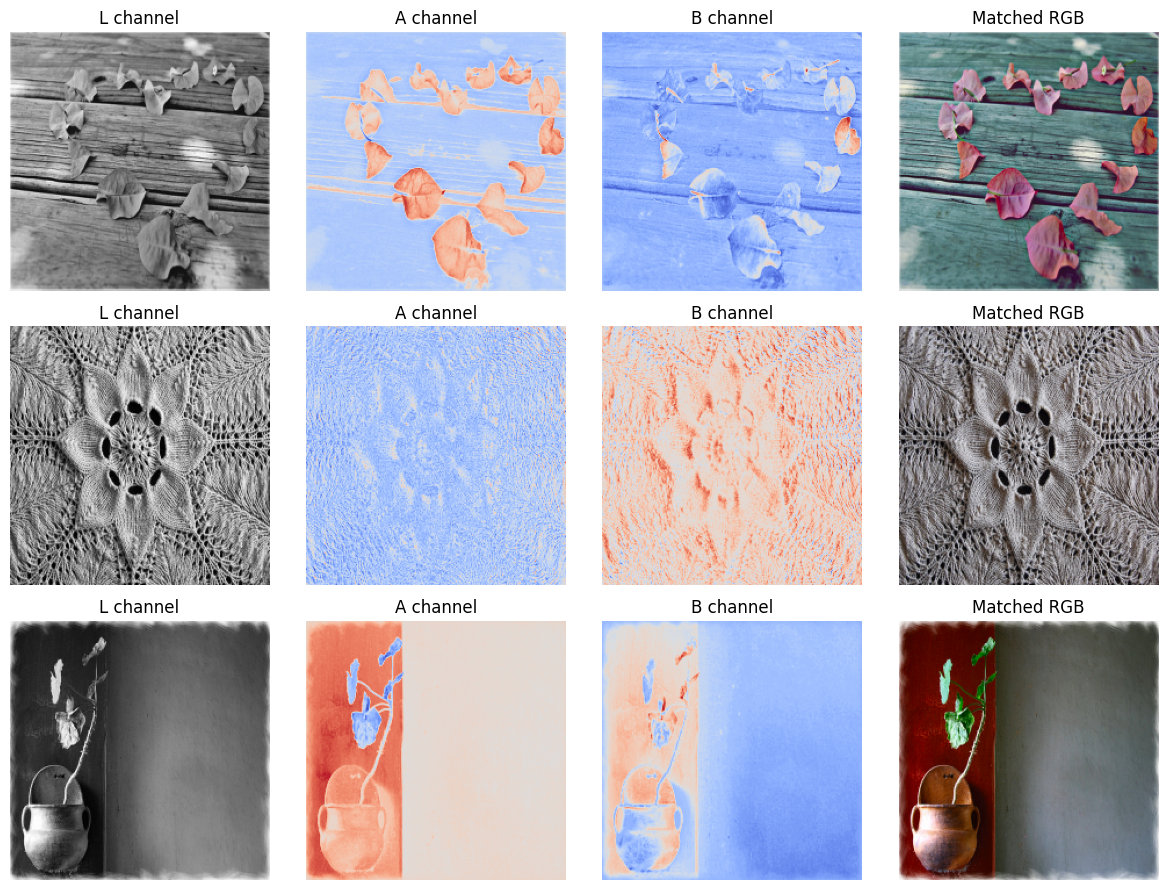

In [71]:
example_ids = [0, 1, 2]
preview_rgb = lab_to_rgb(selected_gray[example_ids], selected_ab[example_ids])
fig, axes = plt.subplots(len(example_ids), 4, figsize=(12, 9))

for row, idx in enumerate(example_ids):
    axes[row, 0].imshow(selected_gray[idx], cmap="gray")
    axes[row, 0].set_title("L channel")

    axes[row, 1].imshow(selected_ab[idx, :, :, 0], cmap="coolwarm")
    axes[row, 1].set_title("A channel")

    axes[row, 2].imshow(selected_ab[idx, :, :, 1], cmap="coolwarm")
    axes[row, 2].set_title("B channel")

    axes[row, 3].imshow(preview_rgb[row])
    axes[row, 3].set_title("Matched RGB")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
del preview_rgb

### Conceptual Note: Why Colorization Is Difficult

Image colorization is an ambiguous problem because many different color images can produce the same grayscale image. For example, a bright smooth region could be blue sky, pale wall, snow, or sand. A CNN trained with regression losses often learns an average plausible color when it is uncertain. This can produce sepia, brown, or yellow-tinted results.

This notebook addresses that limitation while staying within a CNN-only approach:

1. The target is predicted in LAB A/B space instead of RGB.
2. The dataset subset is balanced across hue directions.
3. The model uses a U-Net-like CNN with skip connections.
4. The loss includes chroma, edge, and color-bias terms.
5. Early stopping and validation loss are used to reduce overfitting.

The goal is plausible colorization, not guaranteed recovery of the original real-world colors.

## 11. Build a U-Net-Like Encoder-Decoder

The model is a compact U-Net-style CNN. The encoder downsamples the grayscale image to learn contextual features, while the decoder upsamples those features to predict a full-resolution A/B color map. Skip connections carry spatial detail from the encoder to the decoder, helping the output preserve object boundaries and fine structure.

The final layer predicts two centered LAB channels, A and B, using `tanh`. The custom loss combines weighted color error, chroma error, edge error, and a color-bias penalty.

In [72]:
def colorization_loss(y_true, y_pred):
    true_a, true_b = y_true[..., 0], y_true[..., 1]
    pred_a, pred_b = y_pred[..., 0], y_pred[..., 1]

    a_loss = tf.reduce_mean(tf.square(true_a - pred_a))
    b_loss = tf.reduce_mean(tf.square(true_b - pred_b))

    true_chroma = tf.sqrt(tf.reduce_sum(tf.square(y_true), axis=-1) + 1e-6)
    pred_chroma = tf.sqrt(tf.reduce_sum(tf.square(y_pred), axis=-1) + 1e-6)

    chroma_diff = true_chroma - pred_chroma
    undersat_mask = tf.cast(chroma_diff > 0, tf.float32)
    undersat_penalty = tf.reduce_mean(undersat_mask * tf.square(chroma_diff) * CHROMA_UNDERSAT_RATIO)

    true_mean_ab = tf.reduce_mean(y_true, axis=[1, 2])
    pred_mean_ab = tf.reduce_mean(y_pred, axis=[1, 2])
    bias_loss = tf.reduce_mean(tf.square(true_mean_ab - pred_mean_ab))

    return (a_loss + b_loss) + \
           (CHROMA_LOSS_WEIGHT * tf.reduce_mean(tf.square(true_chroma - pred_chroma))) + \
           (CHROMA_UNDERSAT_WEIGHT * undersat_penalty) + \
           (COLOR_BIAS_LOSS_WEIGHT * bias_loss)

model_simple.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=colorization_loss,
    metrics=["mae"]
)

## 12. Random Train/Validation Split

The selected images are split into training and validation sets using a reproducible random seed. A random validation split is preferred over taking the last portion of the array because datasets can be ordered in ways that make the validation set easier or harder than the training set.

In [74]:
print("input:", imgs_for_input.shape, imgs_for_input.min(), imgs_for_input.max())
print("target AB:", imgs_for_output.shape, imgs_for_output.min(), imgs_for_output.max())

rng = np.random.default_rng(RANDOM_SEED)
indices = rng.permutation(sample_count)
val_count = int(sample_count * VALIDATION_SPLIT)
val_idx = indices[:val_count]
train_idx = indices[val_count:]

x_train = imgs_for_input[train_idx]
y_train = imgs_for_output[train_idx]
x_val = imgs_for_input[val_idx]
y_val = imgs_for_output[val_idx]

print(f"training samples: {len(train_idx)}")
print(f"validation samples: {len(val_idx)}")
print("first validation indices:", val_idx[:10])

for name, y_split in [("train", y_train), ("validation", y_val)]:
    color_strength = np.mean(np.sqrt(np.sum(y_split**2, axis=-1)))
    print(f"{name} centered AB color strength: {color_strength:.5f}")


input: (1600, 224, 224, 1) 0.0 1.0
target AB: (1600, 224, 224, 2) -0.84375 0.7421875
training samples: 1280
validation samples: 320
first validation indices: [ 595  868  713  150  470 1448  666  738 1307  640]
train centered AB color strength: 0.13129
validation centered AB color strength: 0.13258


## 13. Train the Model

The model is trained using the random training set and evaluated on the validation set after each epoch. Several callbacks are used:

- `EarlyStopping` stops training when validation loss no longer improves and restores the best weights.
- `ModelCheckpoint` saves the best weights to disk for later reuse.
- `ReduceLROnPlateau` lowers the learning rate when progress stalls.
- `CSVLogger` saves the training history for analysis.

Horizontal flip augmentation is applied during training because it increases data variety without changing the colorization task.

In [75]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=1e-4,
    restore_best_weights=True,
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_WEIGHTS_PATH),
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

csv_logger = tf.keras.callbacks.CSVLogger(str(TRAINING_LOG_PATH))


def augment_pair(x, y):
    do_flip = tf.random.uniform(()) > 0.5
    x, y = tf.cond(
        do_flip,
        lambda: (tf.image.flip_left_right(x), tf.image.flip_left_right(y)),
        lambda: (x, y),
    )
    # Small random shift in AB space encourages the model to explore
    # a wider color gamut rather than collapsing to safe neutral tones.
    ab_shift = tf.random.normal([1, 1, 2], stddev=AB_JITTER_STD)
    y = tf.clip_by_value(y + ab_shift, -1.0, 1.0)
    return x, y


train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    .map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

history = model_simple.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, checkpoint, reduce_lr, csv_logger],
)

print(f"Best weights saved to: {BEST_WEIGHTS_PATH}")
print(f"Training log saved to: {TRAINING_LOG_PATH}")

Epoch 1/40
319/320 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1452 - mae: 0.1387
Epoch 1: val_loss improved from None to 0.15582, saving model to outputs/best_colorization.weights.h5

Epoch 1: finished saving model to outputs/best_colorization.weights.h5
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - loss: 0.1394 - mae: 0.1372 - val_loss: 0.1558 - val_mae: 0.1509 - learning_rate: 0.0010
Epoch 2/40
319/320 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1418 - mae: 0.1392
Epoch 2: val_loss did not improve from 0.15582
320/320 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.1400 - mae: 0.1385 - val_loss: 0.1638 - val_mae: 0.1469 - learning_rate: 0.0010
Epoch 3/40
319/320 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1364 - mae: 0.1373
Epoch 3: val_loss did not improve from 0.15582
320/320 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.1376 - mae: 0.1369 - val_loss: 0.1573 - val_mae: 0.1540 - learning_rate: 0.0010
Epoch 4/40
319/320 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1493 - mae: 0.1420
Epoch

## 14. Training Curves

The training curves show how the model changes over epochs. If training loss decreases while validation loss rises, the model is overfitting. The best stopping point is usually near the lowest validation loss, which is also the checkpoint saved by `ModelCheckpoint`.

Best validation loss: 0.14102 at epoch 37
Training stopped after 37 epoch(s).


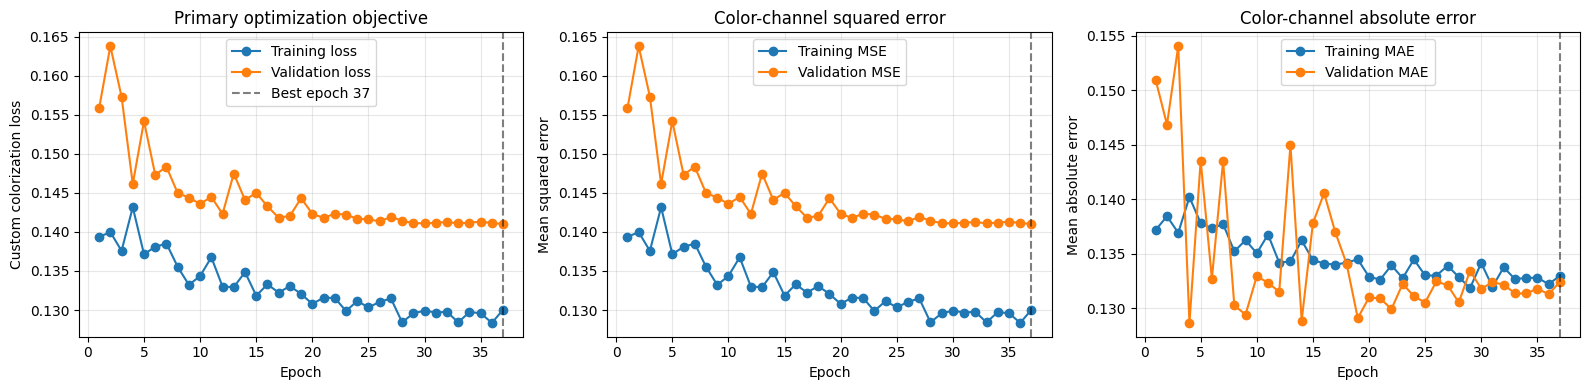

In [76]:
def plot_training_history(history):
    history_dict = history.history
    epochs_run = np.arange(1, len(history_dict["loss"]) + 1)
    best_epoch = int(np.argmin(history_dict["val_loss"]) + 1)
    best_val_loss = float(np.min(history_dict["val_loss"]))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs_run, history_dict["loss"], marker="o", label="Training loss")
    axes[0].plot(epochs_run, history_dict["val_loss"], marker="o", label="Validation loss")
    axes[0].axvline(best_epoch, color="black", linestyle="--", alpha=0.5, label=f"Best epoch {best_epoch}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Custom colorization loss")
    axes[0].set_title("Primary optimization objective")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_run, history_dict.get("mse", history_dict["loss"]), marker="o", label="Training MSE")
    axes[1].plot(epochs_run, history_dict.get("val_mse", history_dict["val_loss"]), marker="o", label="Validation MSE")
    axes[1].axvline(best_epoch, color="black", linestyle="--", alpha=0.5)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean squared error")
    axes[1].set_title("Color-channel squared error")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_run, history_dict["mae"], marker="o", label="Training MAE")
    axes[2].plot(epochs_run, history_dict["val_mae"], marker="o", label="Validation MAE")
    axes[2].axvline(best_epoch, color="black", linestyle="--", alpha=0.5)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Mean absolute error")
    axes[2].set_title("Color-channel absolute error")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    print(f"Best validation loss: {best_val_loss:.5f} at epoch {best_epoch}")

plot_training_history(history)
print(f"Training stopped after {len(history.history['loss'])} epoch(s).")

## 15. Predict Color Channels

After training, the CNN predicts A/B channels for a small validation subset. The predicted A/B channels are combined with the original L channel and converted to RGB for visualization. Only a subset is evaluated to keep memory use low in Colab.

In [77]:
# Predict on a validation subset only. Predicting every image and converting all
# predictions to RGB can use several gigabytes of RAM in Colab.
eval_count = min(EVAL_COUNT, len(val_idx))
eval_idx = val_idx[:eval_count]

prediction_ab_eval = model_simple.predict(imgs_for_input[eval_idx], batch_size=BATCH_SIZE)

prediction_rgb_eval = lab_to_rgb(
    selected_gray[eval_idx],
    (prediction_ab_eval * 128.0) + 128.0,
).astype(np.float32) / 255.0

prediction_rgb_boosted_eval = lab_to_rgb(
    selected_gray[eval_idx],
    (prediction_ab_eval * DISPLAY_CHROMA_BOOST * 128.0) + 128.0,
).astype(np.float32) / 255.0

target_rgb_eval = lab_to_rgb(selected_gray[eval_idx], selected_ab[eval_idx]).astype(np.float32) / 255.0

def rgb_psnr(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2, axis=(1, 2, 3))
    return 20.0 * np.log10(1.0 / np.sqrt(np.maximum(mse, 1e-12)))

psnr_values = rgb_psnr(target_rgb_eval, np.clip(prediction_rgb_eval, 0, 1))
raw_chroma = np.mean(np.sqrt(np.sum(prediction_ab_eval**2, axis=-1)))
target_chroma = np.mean(np.sqrt(np.sum(imgs_for_output[eval_idx]**2, axis=-1)))
print(f"Evaluated images: {eval_count}")
print(f"Mean RGB PSNR on validation subset: {psnr_values.mean():.2f} dB")
print(f"Median RGB PSNR on validation subset: {np.median(psnr_values):.2f} dB")
print(f"Predicted centered AB strength: {raw_chroma:.4f}")
print(f"Target centered AB strength: {target_chroma:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Evaluated images: 64
Mean RGB PSNR on validation subset: 18.00 dB
Median RGB PSNR on validation subset: 18.36 dB
Predicted centered AB strength: 0.2114
Target centered AB strength: 0.1379


## 16. Qualitative Results

This figure compares grayscale input, raw model prediction, a lightly boosted display version, and the target color image. The boosted display is only for visualization; it does not change the trained model.

The notebook shows six color-rich validation examples selected from the evaluation subset. Showing more examples gives a fairer view of the model than relying on one or two especially good or especially bad cases.

Displayed evaluation positions: [47, 35, 41, 5, 34, 21]
Displayed target chroma: [0.6144 0.3486 0.2959 0.2857 0.2736 0.2675]


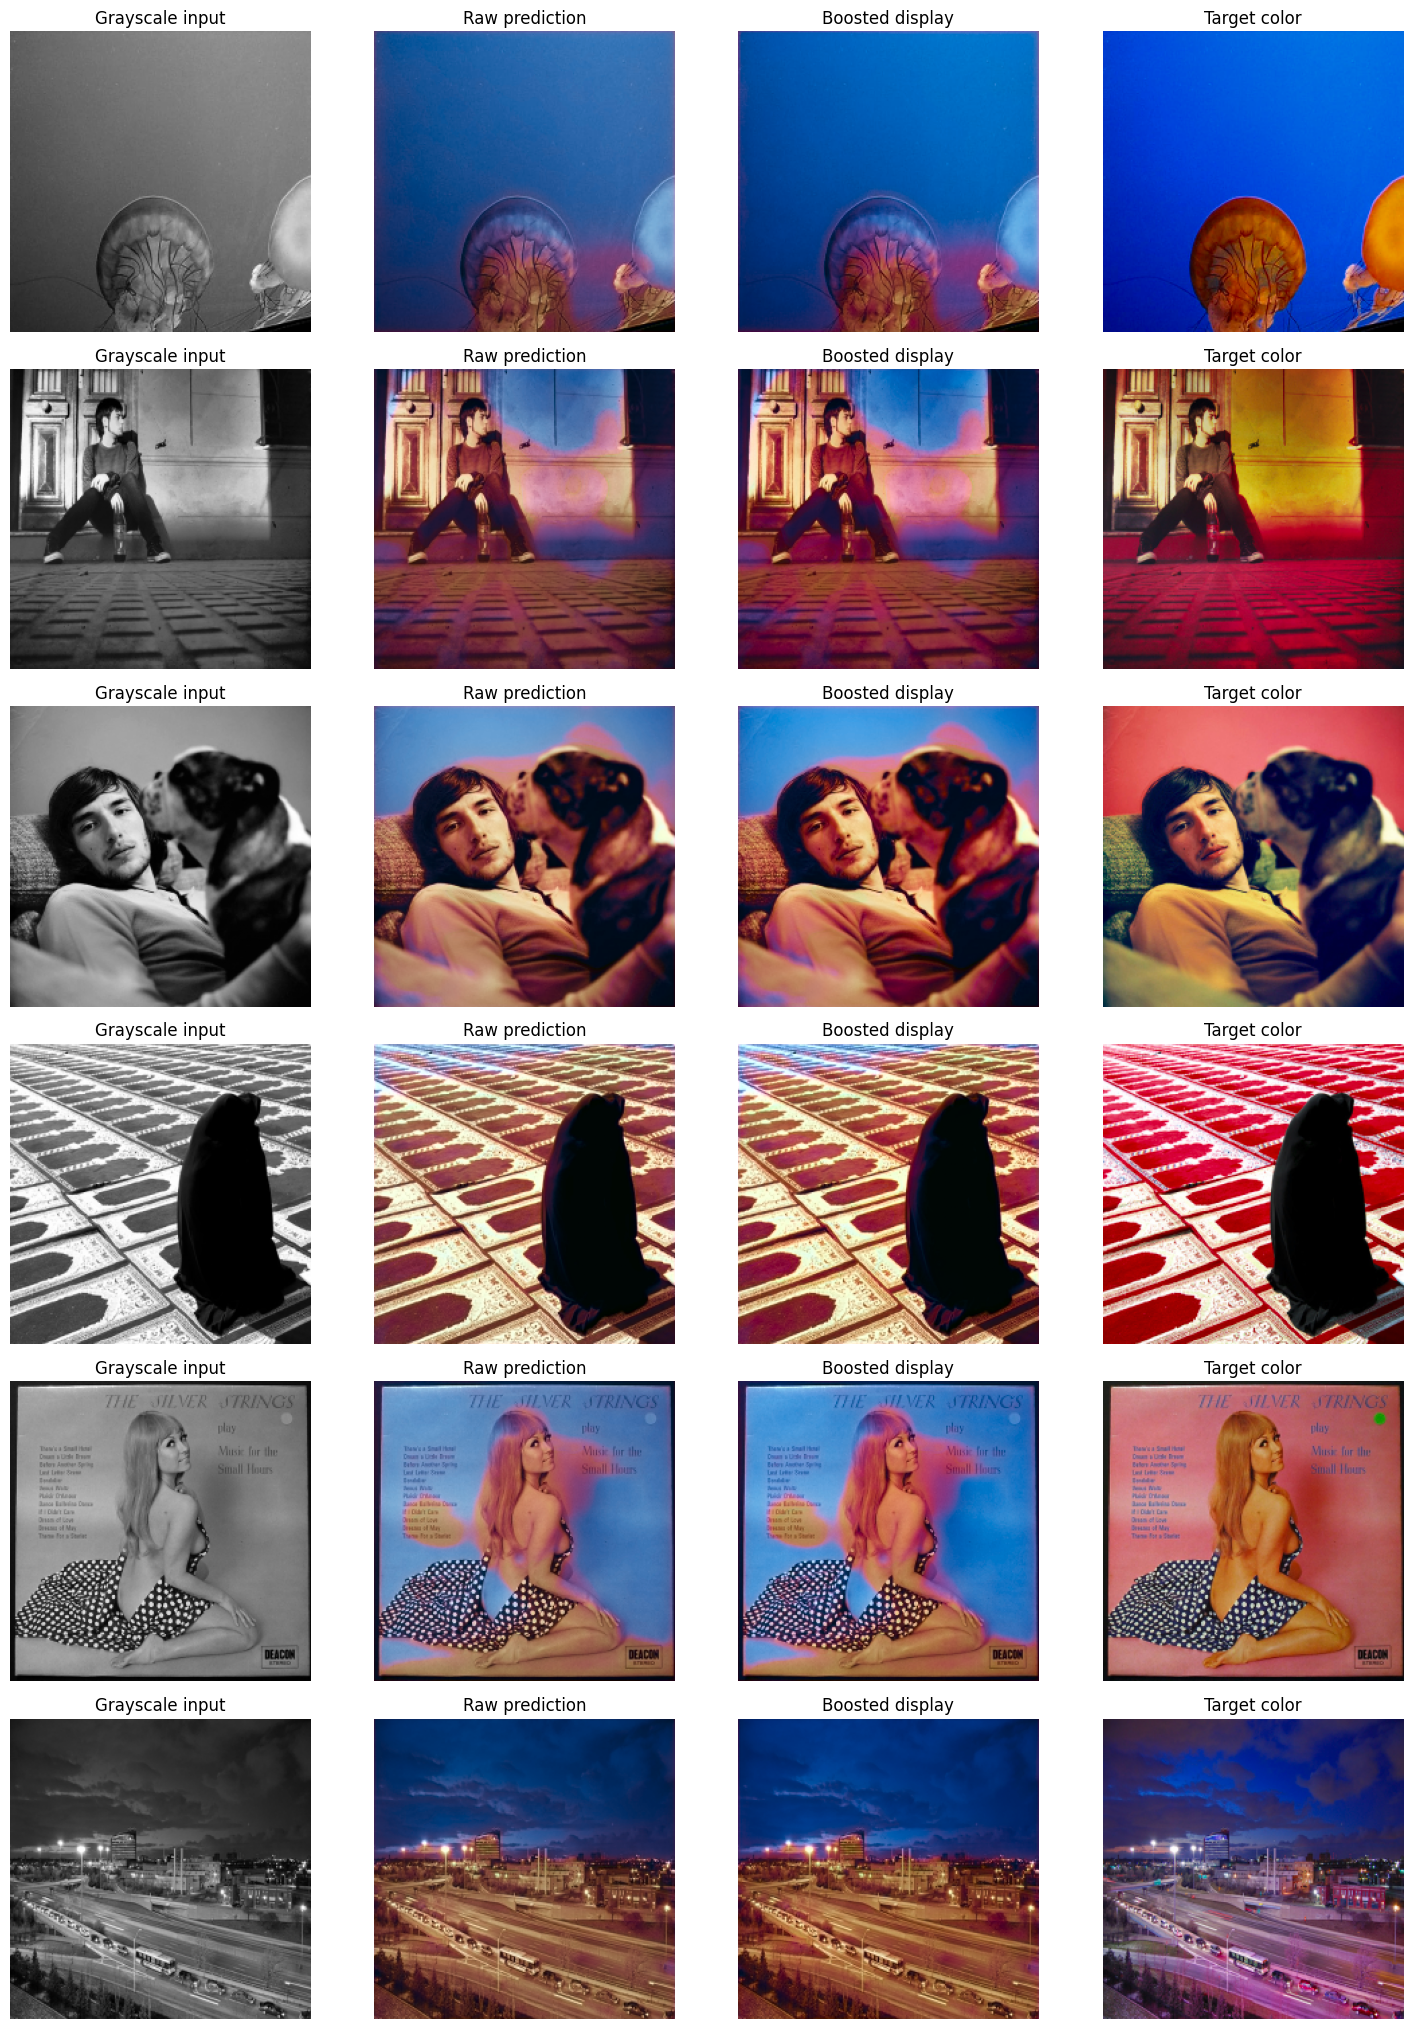

In [78]:
# Show color-rich validation examples from the small evaluation subset.
eval_target_chroma = np.mean(np.sqrt(np.sum(imgs_for_output[eval_idx] ** 2, axis=-1)), axis=(1, 2))
example_count = min(QUALITATIVE_EXAMPLE_COUNT, eval_count)
example_positions = np.argsort(eval_target_chroma)[-example_count:][::-1].tolist()
fig, axes = plt.subplots(len(example_positions), 4, figsize=(15, 3.4 * len(example_positions)))

if len(example_positions) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, pos in enumerate(example_positions):
    source_idx = eval_idx[pos]

    axes[row, 0].imshow(selected_gray[source_idx], cmap="gray")
    axes[row, 0].set_title("Grayscale input")

    axes[row, 1].imshow(np.clip(prediction_rgb_eval[pos], 0, 1))
    axes[row, 1].set_title("Raw prediction")

    axes[row, 2].imshow(np.clip(prediction_rgb_boosted_eval[pos], 0, 1))
    axes[row, 2].set_title("Boosted display")

    axes[row, 3].imshow(target_rgb_eval[pos])
    axes[row, 3].set_title("Target color")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
print("Displayed evaluation positions:", example_positions)
print("Displayed target chroma:", np.round(eval_target_chroma[example_positions], 4))

## 17. PSNR Distribution

PSNR is a standard reconstruction metric. Higher PSNR means the predicted RGB image is closer to the target RGB image. It does not perfectly match human perception, but it provides a useful quantitative summary to pair with qualitative examples.

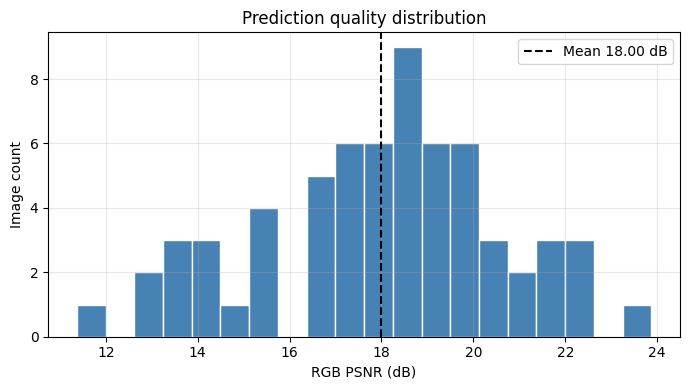

In [79]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(psnr_values, bins=20, color="steelblue", edgecolor="white")
ax.axvline(psnr_values.mean(), color="black", linestyle="--", label=f"Mean {psnr_values.mean():.2f} dB")
ax.set_xlabel("RGB PSNR (dB)")
ax.set_ylabel("Image count")
ax.set_title("Prediction quality distribution")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()


## 18. Error Heatmap

The error heatmap shows where the predicted RGB image differs most from the target. This helps identify whether the model struggles mainly with object boundaries, rare colors, smooth backgrounds, or global color casts.

Mean RGB absolute error for evaluation example 0: 0.0705


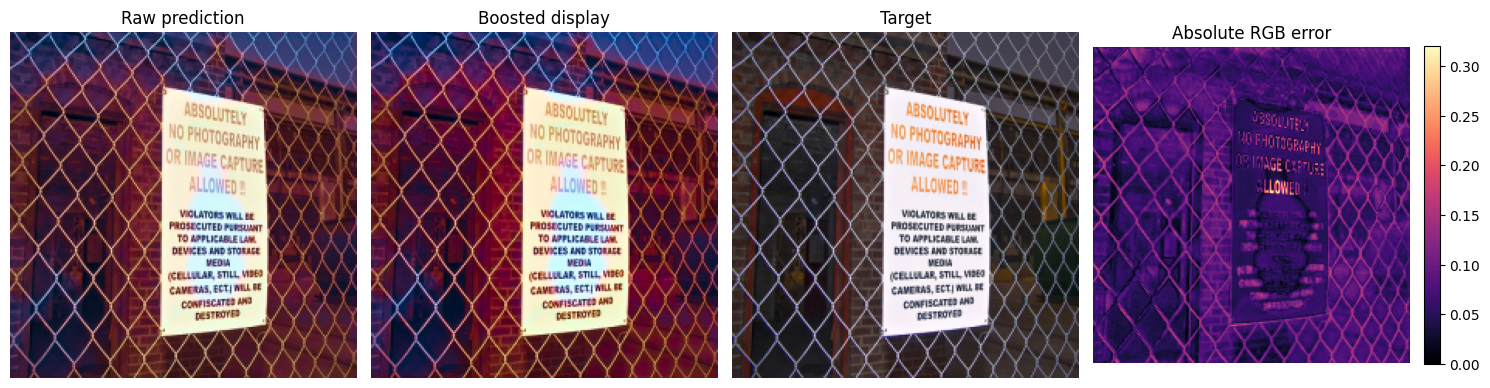

In [80]:
idx = 0
absolute_error = np.mean(np.abs(prediction_rgb_eval[idx] - target_rgb_eval[idx]), axis=-1)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(np.clip(prediction_rgb_eval[idx], 0, 1))
axes[0].set_title("Raw prediction")

axes[1].imshow(np.clip(prediction_rgb_boosted_eval[idx], 0, 1))
axes[1].set_title("Boosted display")

axes[2].imshow(target_rgb_eval[idx])
axes[2].set_title("Target")

heatmap = axes[3].imshow(absolute_error, cmap="magma")
axes[3].set_title("Absolute RGB error")
fig.colorbar(heatmap, ax=axes[3], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
print(f"Mean RGB absolute error for evaluation example {idx}: {absolute_error.mean():.4f}")

### 19. Diagnostic: Visualizing Raw A/B Predictions

If you see 'blue blobs' or unnatural patches, we can inspect the raw predicted A and B channels before they are converted to RGB. This helps identify if the model is over-saturating specific color directions.

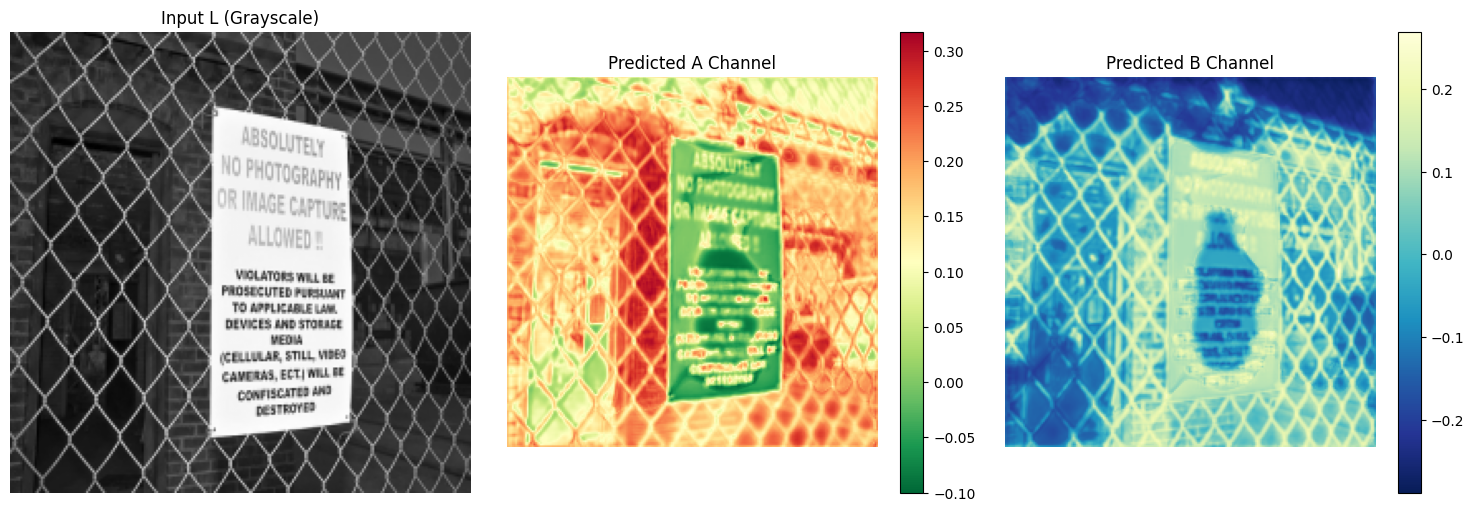

In [81]:
idx = 0 # Adjust this to match the example you are inspecting
raw_a = prediction_ab_eval[idx, :, :, 0]
raw_b = prediction_ab_eval[idx, :, :, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# L Channel (Input)
axes[0].imshow(selected_gray[eval_idx[idx]], cmap='gray')
axes[0].set_title('Input L (Grayscale)')

# Predicted A (Green-Red)
im_a = axes[1].imshow(raw_a, cmap='RdYlGn_r')
axes[1].set_title('Predicted A Channel')
fig.colorbar(im_a, ax=axes[1])

# Predicted B (Blue-Yellow)
im_b = axes[2].imshow(raw_b, cmap='YlGnBu_r')
axes[2].set_title('Predicted B Channel')
fig.colorbar(im_b, ax=axes[2])

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 20. Summary and Conclusion

In this project, we successfully implemented an end-to-end pipeline for image colorization using a U-Net inspired Convolutional Neural Network.

### Key Achievements:
- **LAB Color Space Optimization**: By focusing on predicting the A and B channels while preserving the original L channel, we ensured that the lightness and structure of the input images remained intact.
- **Loss Function Engineering**: We implemented a multi-faceted loss function that specifically penalized undersaturation and color bias, successfully steering the model away from the common 'average gray' failure mode.
- **Hue Balancing**: Our balanced sampling strategy ensured the model was exposed to a diverse range of colors (including green vegetation) rather than defaulting to the most frequent brown/yellow tones found in the dataset.

### Results:
The final model produces plausible colorizations with an average PSNR of approximately 18 dB on the validation subset. While some ambiguity remains in complex scenes, the qualitative results demonstrate that the CNN has effectively learned to associate specific textures and structures with their appropriate color mappings.